# PointNet – Notebook final (version propre)

Ce notebook contient une version claire et compacte pour le TP :
- **PointMLP** (Ex.1)
- **PointNetBasic** sans T-Net (Ex.2.1)
- **PointNetFull** avec **T-Net 3×3** + régularisation (Ex.2.2)
- Pipeline d'augmentations composables avant entraînement (Ex.3)


## 1) Imports


In [44]:
import os
import sys
import math
import time
import random
from typing import List, Optional

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Import local du lecteur PLY

_CODE_DIR = "/content/Pointclouds-classification-with-the-POINTNET-Neural-network/PointNetLab/Code"
sys.path.insert(0, _CODE_DIR)
from ply import read_ply



def set_global_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Reproductibilité (au prix de performances potentiellement moindres)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



## 2) Augmentations (composables)

Tu peux choisir les augmentations via la liste `AUGMENTATIONS_TRAIN` plus bas.


In [45]:
class RandomRotationZ(object):
    def __call__(self, pointcloud: np.ndarray):
        theta = random.random() * 2.0 * math.pi
        rot = np.array([
            [math.cos(theta), -math.sin(theta), 0.0],
            [math.sin(theta),  math.cos(theta), 0.0],
            [0.0,              0.0,             1.0],
        ], dtype=np.float32)
        return pointcloud @ rot.T


class RandomNoise(object):
    def __init__(self, std: float = 0.02):
        self.std = std

    def __call__(self, pointcloud: np.ndarray):
        noise = np.random.normal(0.0, self.std, pointcloud.shape).astype(np.float32)
        return pointcloud + noise


class ShufflePoints(object):
    def __call__(self, pointcloud: np.ndarray):
        out = pointcloud.copy()
        np.random.shuffle(out)
        return out


class RandomScale(object):
    def __init__(self, low: float = 0.85, high: float = 1.20):
        self.low = low
        self.high = high

    def __call__(self, pointcloud: np.ndarray):
        s = np.random.uniform(self.low, self.high)
        return pointcloud * np.float32(s)


class RandomTranslate(object):
    def __init__(self, shift: float = 0.10):
        self.shift = shift

    def __call__(self, pointcloud: np.ndarray):
        t = np.random.uniform(-self.shift, self.shift, size=(1, 3)).astype(np.float32)
        return pointcloud + t


class RandomJitterClip(object):
    def __init__(self, sigma: float = 0.01, clip: float = 0.04):
        self.sigma = sigma
        self.clip = clip

    def __call__(self, pointcloud: np.ndarray):
        jit = self.sigma * np.random.randn(*pointcloud.shape).astype(np.float32)
        jit = np.clip(jit, -self.clip, self.clip)
        return pointcloud + jit


class RandomMirrorXY(object):
    def __init__(self, p: float = 0.3):
        self.p = p

    def __call__(self, pointcloud: np.ndarray):
        if random.random() >= self.p:
            return pointcloud
        out = pointcloud.copy()
        axis = random.choice([0, 1])
        out[:, axis] = -out[:, axis]
        return out


class RandomPointDropout(object):
    def __init__(self, max_ratio: float = 0.45):
        self.max_ratio = max_ratio

    def __call__(self, pointcloud: np.ndarray):
        out = pointcloud.copy()
        n = out.shape[0]
        ratio = np.random.uniform(0.0, self.max_ratio)
        drop_idx = np.where(np.random.random(n) <= ratio)[0]
        if len(drop_idx) > 0:
            out[drop_idx] = out[0]
        return out


class RandomSphericalOcclusion(object):
    def __init__(self, radius: float = 0.18, p: float = 0.25):
        self.radius = radius
        self.p = p

    def __call__(self, pointcloud: np.ndarray):
        if random.random() >= self.p:
            return pointcloud

        out = pointcloud.copy()
        center = out[np.random.randint(0, out.shape[0])]
        d = np.linalg.norm(out - center[None, :], axis=1)
        keep_mask = d > self.radius

        if np.sum(keep_mask) < 8:
            return out

        kept = out[keep_mask]
        if kept.shape[0] >= out.shape[0]:
            return kept[: out.shape[0]]

        extra_idx = np.random.choice(kept.shape[0], out.shape[0] - kept.shape[0], replace=True)
        return np.concatenate([kept, kept[extra_idx]], axis=0)


class UnitSphereNormalize(object):
    def __call__(self, pointcloud: np.ndarray):
        centered = pointcloud - np.mean(pointcloud, axis=0, keepdims=True)
        norms = np.linalg.norm(centered, axis=1)
        m = float(np.max(norms)) if norms.size else 1.0
        if m < 1e-12:
            return centered.astype(np.float32)
        return (centered / m).astype(np.float32)


class ToTensor(object):
    def __call__(self, pointcloud: np.ndarray):
        return torch.from_numpy(pointcloud.astype(np.float32))


AUGMENTATION_REGISTRY = {
    "rot_z": lambda: RandomRotationZ(),
    "noise": lambda: RandomNoise(std=0.02),
    "shuffle": lambda: ShufflePoints(),
    "scale": lambda: RandomScale(low=0.85, high=1.20),
    "translate": lambda: RandomTranslate(shift=0.10),
    "jitter": lambda: RandomJitterClip(sigma=0.01, clip=0.04),
    "mirror": lambda: RandomMirrorXY(p=0.3),
    "dropout": lambda: RandomPointDropout(max_ratio=0.45),
    "occlusion": lambda: RandomSphericalOcclusion(radius=0.18, p=0.25),
    "normalize": lambda: UnitSphereNormalize(),
}


def build_transforms(selected: Optional[List[str]] = None):
    selected = selected or []
    ops = [AUGMENTATION_REGISTRY[name]() for name in selected]
    ops.append(ToTensor())
    return transforms.Compose(ops)



### Politique d'augmentation recommandée (baseline fixe + mix aléatoire)

Idée: baseline constante + occlusion 50% du temps + une augmentation aléatoire (parmi une liste) 50% du temps.


In [46]:
class RandomApply(object):
    def __init__(self, transform, p: float = 0.5):
        self.transform = transform
        self.p = p

    def __call__(self, pointcloud: np.ndarray):
        if random.random() < self.p:
            return self.transform(pointcloud)
        return pointcloud


class RandomChoiceApply(object):
    def __init__(self, transforms_list, p: float = 0.5):
        self.transforms_list = transforms_list
        self.p = p

    def __call__(self, pointcloud: np.ndarray):
        if (not self.transforms_list) or random.random() >= self.p:
            return pointcloud
        t = random.choice(self.transforms_list)
        return t(pointcloud)


def build_train_transforms_occlusion_mix(extra_names=None,
                                         p_occlusion=0.5,
                                         p_extra=0.5,
                                         baseline_names=None):
    baseline_names = baseline_names or ['normalize', 'rot_z', 'noise', 'shuffle']
    extra_names = extra_names or ['scale', 'translate', 'jitter', 'mirror', 'dropout']

    ops = [AUGMENTATION_REGISTRY[name]() for name in baseline_names]
    ops.append(RandomApply(RandomSphericalOcclusion(radius=0.18, p=1.0), p=p_occlusion))

    extra_ops = [AUGMENTATION_REGISTRY[name]() for name in extra_names]
    ops.append(RandomChoiceApply(extra_ops, p=p_extra))
    ops.append(ToTensor())
    return transforms.Compose(ops)



## 3) Dataset ModelNet (PLY)


In [47]:
class PointCloudData(Dataset):
    def __init__(self, root_dir, folder="train", transform=None):
        self.root_dir = root_dir
        self.transforms = transform if transform is not None else build_transforms(["rot_z", "noise", "shuffle"])

        folders = [d for d in sorted(os.listdir(root_dir)) if os.path.isdir(os.path.join(root_dir, d))]
        self.classes = {name: i for i, name in enumerate(folders)}

        self.files = []
        for category in self.classes.keys():
            split_dir = os.path.join(root_dir, category, folder)
            for file in os.listdir(split_dir):
                if file.endswith('.ply'):
                    self.files.append({
                        'ply_path': os.path.join(split_dir, file),
                        'category': category,
                    })

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        sample = self.files[idx]
        data = read_ply(sample['ply_path'])
        pointcloud = np.vstack((data['x'], data['y'], data['z'])).T.astype(np.float32)
        pointcloud = self.transforms(pointcloud)
        label = self.classes[sample['category']]
        return {'pointcloud': pointcloud, 'category': label}



## 4) Réseaux demandés dans l'énoncé


In [48]:
class PointMLP(nn.Module):
    # Ex.1: 3072 -> 512 -> 256 -> N, BN + ReLU, dropout(0.3), LogSoftmax
    def __init__(self, classes=40):
        super().__init__()
        self.flatten = nn.Flatten(start_dim=1)
        self.fc1 = nn.Linear(3072, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.drop = nn.Dropout(0.3)
        self.fc3 = nn.Linear(256, classes)
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.drop(torch.relu(self.bn2(self.fc2(x))))
        x = self.logsoftmax(self.fc3(x))
        return x


class PointNetBasic(nn.Module):
    # Ex.2.1: PointNet sans T-Net
    def __init__(self, classes=40):
        super().__init__()
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 64, 1)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 64, 1)
        self.bn3 = nn.BatchNorm1d(64)
        self.conv4 = nn.Conv1d(64, 128, 1)
        self.bn4 = nn.BatchNorm1d(128)
        self.conv5 = nn.Conv1d(128, 1024, 1)
        self.bn5 = nn.BatchNorm1d(1024)

        self.maxpool = nn.MaxPool1d(1024)
        self.fc1 = nn.Linear(1024, 512)
        self.bn6 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn7 = nn.BatchNorm1d(256)
        self.drop = nn.Dropout(0.3)
        self.fc3 = nn.Linear(256, classes)
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = torch.relu(self.bn3(self.conv3(x)))
        x = torch.relu(self.bn4(self.conv4(x)))
        x = torch.relu(self.bn5(self.conv5(x)))
        x = self.maxpool(x).squeeze(-1)
        x = torch.relu(self.bn6(self.fc1(x)))
        x = self.drop(torch.relu(self.bn7(self.fc2(x))))
        x = self.logsoftmax(self.fc3(x))
        return x


class Tnet(nn.Module):
    # Ex.2.2: mini-PointNet qui régressse une matrice k x k
    def __init__(self, k=3):
        super().__init__()
        self.k = k
        self.conv1 = nn.Conv1d(k, 64, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 1024, 1)
        self.bn3 = nn.BatchNorm1d(1024)

        self.maxpool = nn.MaxPool1d(1024)
        self.fc1 = nn.Linear(1024, 512)
        self.bn4 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn5 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, k * k)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.maxpool(x).squeeze(-1)
        x = torch.relu(self.bn4(self.fc1(x)))
        x = torch.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x).reshape(x.size(0), self.k, self.k)

        identity = torch.eye(self.k, device=x.device, dtype=x.dtype).unsqueeze(0).repeat(x.size(0), 1, 1)
        return x + identity


class PointNetFull(nn.Module):
    # Ex.2.2 demandé: PointNet avec le 1er T-Net (3x3)
    def __init__(self, classes=40):
        super().__init__()
        self.tnet1 = Tnet(k=3)

        self.conv1 = nn.Conv1d(3, 64, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 64, 1)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 64, 1)
        self.bn3 = nn.BatchNorm1d(64)
        self.conv4 = nn.Conv1d(64, 128, 1)
        self.bn4 = nn.BatchNorm1d(128)
        self.conv5 = nn.Conv1d(128, 1024, 1)
        self.bn5 = nn.BatchNorm1d(1024)

        self.maxpool = nn.MaxPool1d(1024)
        self.fc1 = nn.Linear(1024, 512)
        self.bn6 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn7 = nn.BatchNorm1d(256)
        self.drop = nn.Dropout(0.3)
        self.fc3 = nn.Linear(256, classes)
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        m3x3 = self.tnet1(x)
        x = torch.bmm(m3x3, x)

        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = torch.relu(self.bn3(self.conv3(x)))
        x = torch.relu(self.bn4(self.conv4(x)))
        x = torch.relu(self.bn5(self.conv5(x)))

        x = self.maxpool(x).squeeze(-1)
        x = torch.relu(self.bn6(self.fc1(x)))
        x = self.drop(torch.relu(self.bn7(self.fc2(x))))
        x = self.logsoftmax(self.fc3(x))
        return x, m3x3



## 5) Fonctions de perte


In [49]:
def basic_loss(outputs, labels):
    criterion = nn.NLLLoss()
    return criterion(outputs, labels)


def pointnet_full_loss(outputs, labels, m3x3, alpha=0.001):
    criterion = nn.NLLLoss()
    bsize = outputs.size(0)
    id3x3 = torch.eye(3, device=outputs.device, dtype=outputs.dtype).unsqueeze(0).repeat(bsize, 1, 1)
    diff3x3 = id3x3 - torch.bmm(m3x3, m3x3.transpose(1, 2))
    return criterion(outputs, labels) + alpha * torch.norm(diff3x3) / float(bsize)



## 6) Train / Eval (compatible MLP, Basic et Full)


In [50]:
def forward_with_model(model, x):
    if isinstance(model, PointMLP):
        out = model(x.transpose(1, 2))
        return out, None
    if isinstance(model, PointNetBasic):
        out = model(x.transpose(1, 2))
        return out, None
    out, m3x3 = model(x.transpose(1, 2))
    return out, m3x3


def evaluate(model, device, loader):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0.0
    with torch.no_grad():
        for batch in loader:
            x = batch['pointcloud'].to(device).float()
            y = batch['category'].to(device)
            out, m3x3 = forward_with_model(model, x)

            if isinstance(model, PointNetFull):
                loss = pointnet_full_loss(out, y, m3x3)
            else:
                loss = basic_loss(out, y)

            pred = out.argmax(dim=1)
            bs = y.size(0)
            total += bs
            correct += (pred == y).sum().item()
            loss_sum += loss.item() * bs

    acc = 100.0 * correct / max(1, total)
    avg_loss = loss_sum / max(1, total)
    return acc, avg_loss


def predict_with_labels(model, device, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            x = batch['pointcloud'].to(device).float()
            y = batch['category'].to(device)
            out, _ = forward_with_model(model, x)
            pred = out.argmax(dim=1)
            y_true.extend(y.cpu().numpy().tolist())
            y_pred.extend(pred.cpu().numpy().tolist())
    return np.array(y_true, dtype=np.int64), np.array(y_pred, dtype=np.int64)


def train(model,
          device,
          train_loader,
          val_loader=None,
          epochs=25,
          lr=1e-3,
          use_early_stopping=False,
          early_stop_patience=8,
          early_stop_min_delta=0.0,
          monitor='val_acc'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    stopper = None
    if use_early_stopping:
        stopper = EarlyStopper(patience=early_stop_patience,
                               min_delta=early_stop_min_delta,
                               mode='max' if monitor == 'val_acc' else 'min')

    history = {
        'epoch': [],
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }

    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for batch in train_loader:
            x = batch['pointcloud'].to(device).float()     # (B, N, 3)
            y = batch['category'].to(device)

            optimizer.zero_grad()
            out, m3x3 = forward_with_model(model, x)

            if isinstance(model, PointNetFull):
                loss = pointnet_full_loss(out, y, m3x3)
            else:
                loss = basic_loss(out, y)

            loss.backward()
            optimizer.step()

            bs = y.size(0)
            train_total += bs
            train_loss_sum += loss.item() * bs
            train_correct += (out.argmax(dim=1) == y).sum().item()

        scheduler.step()

        train_loss = train_loss_sum / max(1, train_total)
        train_acc = 100.0 * train_correct / max(1, train_total)

        val_acc, val_loss = (None, None)
        if val_loader is not None:
            val_acc, val_loss = evaluate(model, device, val_loader)
            print(f"Epoch {epoch+1:03d} | train_loss={train_loss:.4f} | train_acc={train_acc:.2f}% | val_loss={val_loss:.4f} | val_acc={val_acc:.2f}%")

        history['epoch'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loader is not None and stopper is not None:
            monitor_value = val_acc if monitor == 'val_acc' else val_loss
            if stopper.step(monitor_value, model):
                print(f"Early stopping déclenché à l'epoch {epoch+1}")
                stopper.restore(model)
                break

    return history



## 7) Early stopping (optionnel)

Permet de garder un **max epoch** pour le protocole, tout en arrêtant si la **validation** n'améliore plus.
Le **test** est gardé pour l'évaluation finale uniquement.


In [51]:
class EarlyStopper:
    def __init__(self, patience=8, min_delta=0.0, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best = None
        self.counter = 0
        self.best_state = None

    def _is_improvement(self, value):
        if self.best is None:
            return True
        if self.mode == 'max':
            return value > (self.best + self.min_delta)
        return value < (self.best - self.min_delta)

    def step(self, value, model):
        if self._is_improvement(value):
            self.best = value
            self.counter = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state is None:
            return
        model.load_state_dict(self.best_state)




## 8) Configuration entraînement

- Choisis ici les augmentations que tu veux composer.
- Pour le test, on applique en général seulement `normalize` (ou rien).


In [52]:
# --- Reproductibilité ---
GLOBAL_SEED = 100
set_global_seed(GLOBAL_SEED)

# --- Chemin dataset ---
DATA_ROOT = "/content/Pointclouds-classification-with-the-POINTNET-Neural-network/PointNetLab/data/ModelNet10_PLY"  # adapte si besoin

# --- Composition des augmentations ---
AUGMENTATIONS_TRAIN = ['normalize', 'rot_z', 'noise', 'shuffle']
AUGMENTATIONS_VAL = ['normalize']
AUGMENTATIONS_TEST = ['normalize']

# Politique demandée: baseline constante + occlusion 50% + 1 augmentation aléatoire 50%
USE_OCCLUSION_MIX_POLICY = True
EXTRA_RANDOM_AUGS = ['scale', 'translate', 'jitter', 'mirror', 'dropout']
P_OCCLUSION = 0.8
P_EXTRA = 0.2

VAL_RATIO = 0.2
SPLIT_SEED = GLOBAL_SEED

if USE_OCCLUSION_MIX_POLICY:
    train_tf = build_train_transforms_occlusion_mix(extra_names=EXTRA_RANDOM_AUGS,
                                                    p_occlusion=P_OCCLUSION,
                                                    p_extra=P_EXTRA,
                                                    baseline_names=AUGMENTATIONS_TRAIN)
else:
    train_tf = build_transforms(AUGMENTATIONS_TRAIN)

# Deux vues du split train: une augmentée (train) et une neutre (val)
full_train_ds = PointCloudData(DATA_ROOT, folder='train', transform=train_tf)
full_train_eval_ds = PointCloudData(DATA_ROOT, folder='train', transform=build_transforms(AUGMENTATIONS_VAL))
test_ds = PointCloudData(DATA_ROOT, folder='test', transform=build_transforms(AUGMENTATIONS_TEST))

rng = np.random.RandomState(SPLIT_SEED)
indices = np.arange(len(full_train_ds))
rng.shuffle(indices)
val_size = int(len(indices) * VAL_RATIO)
val_idx = indices[:val_size].tolist()
train_idx = indices[val_size:].tolist()

from torch.utils.data import Subset
train_ds = Subset(full_train_ds, train_idx)
val_ds = Subset(full_train_eval_ds, val_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print('Classes :', len(full_train_ds.classes))
print('Train size:', len(train_ds))
print('Val size  :', len(val_ds))
print('Test size :', len(test_ds))
print('Augs train:', AUGMENTATIONS_TRAIN)
print('Augs val  :', AUGMENTATIONS_VAL)
print('Augs test :', AUGMENTATIONS_TEST)
print('Seed      :', GLOBAL_SEED)
print('Occlusion mix policy:', USE_OCCLUSION_MIX_POLICY, '| p_occ=', P_OCCLUSION, '| p_extra=', P_EXTRA)



Classes : 10
Train size: 3193
Val size  : 798
Test size : 908
Augs train: ['normalize', 'rot_z', 'noise', 'shuffle']
Augs val  : ['normalize']
Augs test : ['normalize']
Seed      : 100
Occlusion mix policy: True | p_occ= 0.8 | p_extra= 0.2


## 9) Visualisation d'un nuage + effet des augmentations

Cette cellule prend un nuage au hasard et affiche l'effet de chaque augmentation (1 par 1).


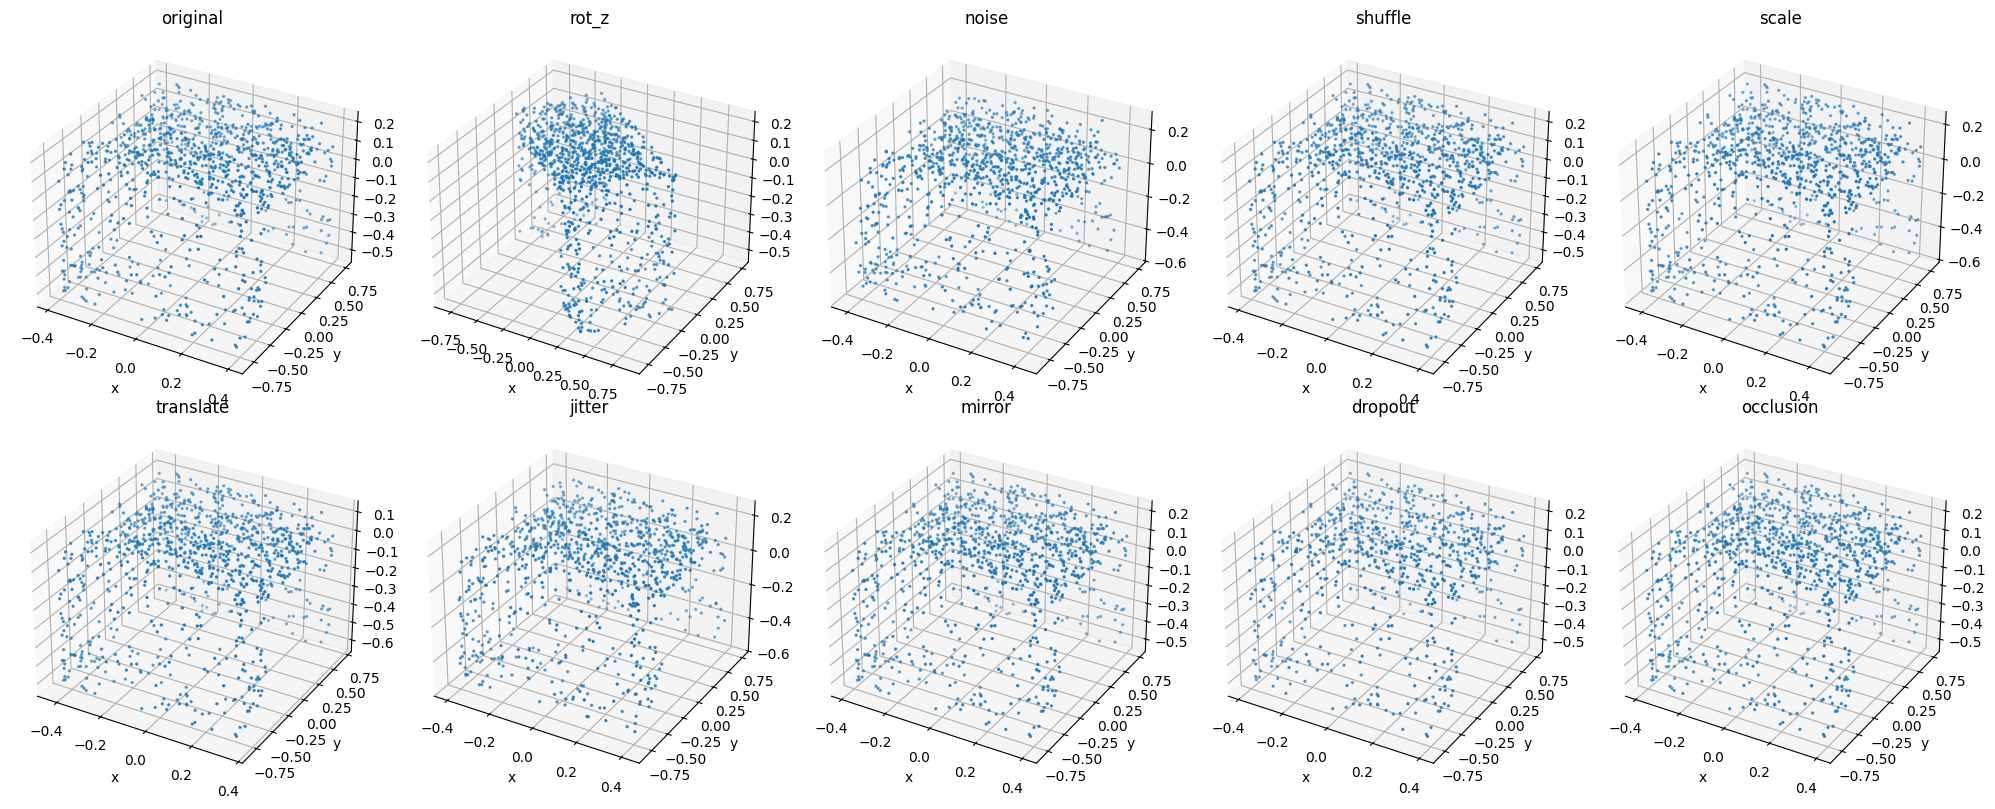

In [53]:
import matplotlib.pyplot as plt


def plot_pointcloud(ax, pc, title):
    ax.scatter(pc[:, 0], pc[:, 1], pc[:, 2], s=2)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')


# Nuage brut choisi aléatoirement dans le train set
rand_idx = np.random.randint(0, len(full_train_ds))
raw_data = read_ply(full_train_ds.files[rand_idx]['ply_path'])
raw_pc = np.vstack((raw_data['x'], raw_data['y'], raw_data['z'])).T.astype(np.float32)

# Augmentations à visualiser (tu peux ajuster la liste)
VIS_AUGS = ['rot_z', 'noise', 'shuffle', 'scale', 'translate', 'jitter', 'mirror', 'dropout', 'occlusion']

ncols = 5
nplots = 1 + len(VIS_AUGS)
nrows = int(np.ceil(nplots / ncols))
fig = plt.figure(figsize=(4*ncols, 4*nrows))

ax = fig.add_subplot(nrows, ncols, 1, projection='3d')
plot_pointcloud(ax, raw_pc, 'original')

for i, aug_name in enumerate(VIS_AUGS, start=2):
    aug = AUGMENTATION_REGISTRY[aug_name]()
    aug_pc = aug(raw_pc.copy())
    ax = fig.add_subplot(nrows, ncols, i, projection='3d')
    plot_pointcloud(ax, aug_pc, aug_name)

plt.tight_layout()
plt.show()




## 10) Choix du modèle et lancement


In [54]:
# Choix: PointMLP / PointNetBasic / PointNetFull
MODEL_NAME = "PointNetFull"
NUM_CLASSES = len(full_train_ds.classes)

if MODEL_NAME == "PointMLP":
    model = PointMLP(classes=NUM_CLASSES)
elif MODEL_NAME == "PointNetBasic":
    model = PointNetBasic(classes=NUM_CLASSES)
elif MODEL_NAME == "PointNetFull":
    model = PointNetFull(classes=NUM_CLASSES)
else:
    raise ValueError(f"Modèle inconnu: {MODEL_NAME}")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Model:', MODEL_NAME)
print('Trainable params:', n_params)
print('Device:', device)



Model: PointNetFull
Trainable params: 1614995
Device: cuda:0


In [55]:
# Lance l'entraînement
MAX_EPOCHS = 50
USE_EARLY_STOPPING = True
EARLY_STOP_PATIENCE = 15
EARLY_STOP_MIN_DELTA = 0.0
EARLY_STOP_MONITOR = 'val_acc'  # early stopping sur validation, pas sur test

# Remarque rapport: garder le même max epochs pour toutes les expériences.
t0 = time.time()
history = train(model,
      device,
      train_loader,
      val_loader=val_loader,
      epochs=MAX_EPOCHS,
      lr=1e-3,
      use_early_stopping=USE_EARLY_STOPPING,
      early_stop_patience=EARLY_STOP_PATIENCE,
      early_stop_min_delta=EARLY_STOP_MIN_DELTA,
      monitor=EARLY_STOP_MONITOR)

# Test utilisé uniquement à la fin
final_test_acc, final_test_loss = evaluate(model, device, test_loader)
y_true_test, y_pred_test = predict_with_labels(model, device, test_loader)
print(f"Final TEST accuracy (évalué une seule fois): {final_test_acc:.2f}%")
print(f"Final TEST loss    (évalué une seule fois): {final_test_loss:.4f}")
print(f"Temps total: {time.time()-t0:.1f}s")



Epoch 001 | train_loss=1.0865 | train_acc=63.17% | val_loss=0.9824 | val_acc=68.55%
Epoch 002 | train_loss=0.7132 | train_acc=75.48% | val_loss=0.7121 | val_acc=76.32%
Epoch 003 | train_loss=0.6438 | train_acc=78.89% | val_loss=0.7681 | val_acc=75.44%
Epoch 004 | train_loss=0.5401 | train_acc=82.09% | val_loss=0.4727 | val_acc=85.84%
Epoch 005 | train_loss=0.4883 | train_acc=83.24% | val_loss=0.4783 | val_acc=83.33%
Epoch 006 | train_loss=0.4625 | train_acc=84.72% | val_loss=0.4672 | val_acc=84.96%
Epoch 007 | train_loss=0.4266 | train_acc=85.66% | val_loss=0.4299 | val_acc=87.22%
Epoch 008 | train_loss=0.4259 | train_acc=85.00% | val_loss=0.3545 | val_acc=87.84%
Epoch 009 | train_loss=0.4079 | train_acc=86.38% | val_loss=0.3174 | val_acc=87.97%
Epoch 010 | train_loss=0.3739 | train_acc=87.35% | val_loss=0.4121 | val_acc=85.46%
Epoch 011 | train_loss=0.3726 | train_acc=87.22% | val_loss=0.5070 | val_acc=83.21%
Epoch 012 | train_loss=0.3822 | train_acc=87.22% | val_loss=0.4006 | val_acc

## 11) Courbes d'évolution (loss et accuracy)


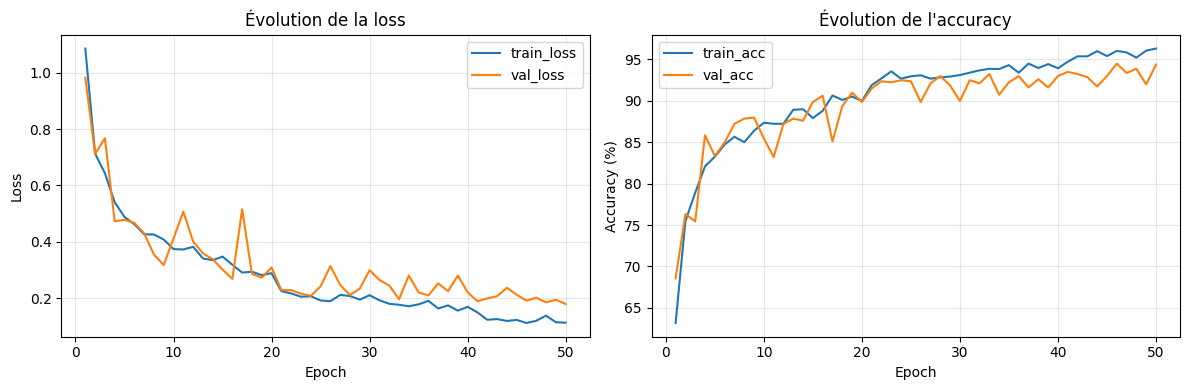

In [56]:
epochs = history['epoch']

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='train_loss')
plt.plot(epochs, history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Évolution de la loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], label='train_acc')
plt.plot(epochs, history['val_acc'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title("Évolution de l'accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




## 12) Matrice de confusion (test)


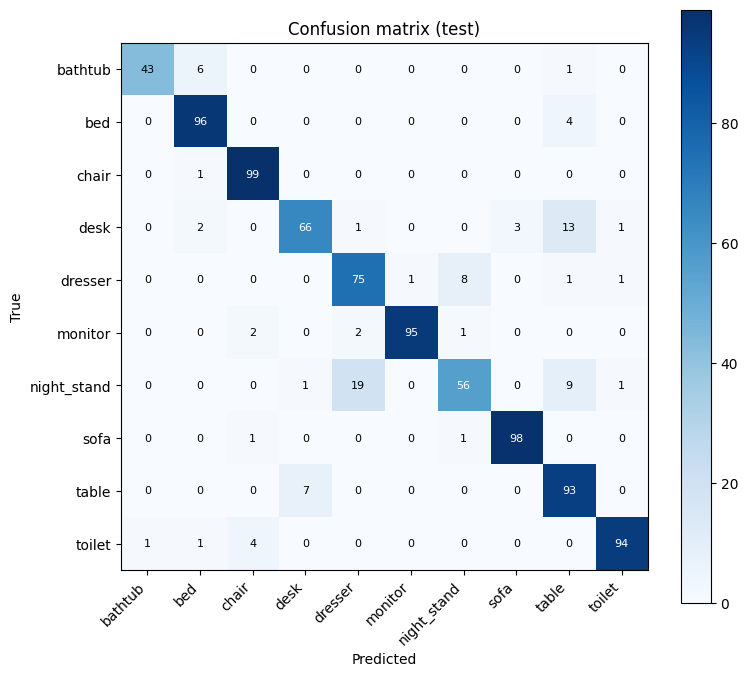

In [57]:
def compute_confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def plot_confusion_matrix(cm, class_names):
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Confusion matrix (test)')

    maxv = cm.max() if cm.size else 1
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if cm[i, j] > maxv * 0.5 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=8)

    plt.tight_layout()
    plt.show()


inv_classes = {i: c for c, i in full_train_ds.classes.items()}
class_names = [inv_classes[i] for i in range(len(inv_classes))]
cm_test = compute_confusion_matrix(y_true_test, y_pred_test, len(class_names))
plot_confusion_matrix(cm_test, class_names)

